# Neutrino fluxes along the muon accelerator chain

Forward neutrino fluxes from muon decays in each machine of the accelerator chain --
the pre-accelerator (PA), the two recirculating linacs (RLA1, RLA2), and the 10 TeV
collider ring -- compared on a single plot for a detector 1 km from the origin of each
machine.

Each machine is simulated separately (no merged PA+RLA lattice): **vegas runs only
once** to generate the master rest-frame decay sample, and every (machine, flavor) case
is an exact `reweighted_copy` placed on that machine's lattice. The rest-frame sample is
machine-independent -- the boost to the lab frame happens at placement, using each
lattice's momentum profile `beam_p0(s)`.

Machine parameters follow `main_RLA_studies.ipynb`; the collider ring is the packaged
`mc_10tev_hybrid_v06` lattice used in `main_collider_ring_studies.ipynb`.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import matplotlib.pyplot as plt

import mint
from mint import const
from mint import lattice_tools as lt
from mint import plot_tools as pt
from mint.MuC import MuDecaySimulator

os.makedirs("plots", exist_ok=True)

## 1. Build the machines

- **PA**: 160 m straight accelerating section, $p_\mu$: 0.225 → 1.25 GeV.
- **RLA1**: recirculating linac (half droplet), 70 m straights, $p_\mu$: 1.25 → 5 GeV.
- **RLA2**: recirculating linac, 829 m straights, $p_\mu$: 5 → 63 GeV.
- **MuC ring**: 10 TeV collider ring ($p_\mu = 5$ TeV), loaded by name from `mint.lattices`.

[2.15768000e+03 2.15780349e+03 2.15792699e+03 ... 1.00000000e-03
 1.00000000e-03 1.00000000e-03]
[ 2157.68        2160.60501144  2163.53002288 ... 17587.56156373
 17590.48657517 17593.4115866 ]
PA: length 160 m, p_mu 0.225 -> 1.25 GeV
RLA1: length 1200 m, p_mu 1.25 -> 5 GeV
RLA2: length 14631 m, p_mu 5 -> 63 GeV
MuC ring: length 1465 m, p_mu 5000 -> 5000 GeV


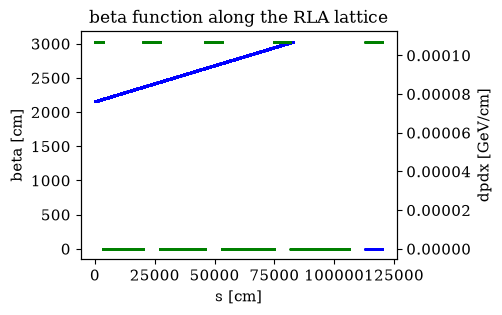

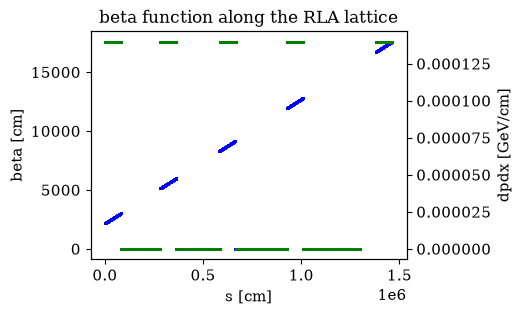

In [2]:
pa_lattice = lt.create_straight_lattice(
    name="PA",
    short_name="pa",
    total_length=160e2,
    n_elements=100_000,
    p0_injected=0.225,
    p0_ejected=1.25,
    beamdiv=1e-3,
    beamdiv_z=1e-2,
    beamsize=1.0,
    Nmu_per_bunch=2e12,
)

rla1_lattice = lt.create_RLA_lattice(
    name="RLA1",
    short_name="rla1",
    straight_length=70e2,
    n_elements=100_000,
    p0_injection=1.25,
    dp_dx_LA=0.75 / 70e2,
    beamdiv_z=1e-2,
    beamdiv=1e-3,
    beamsize=1e-2,
    half=True,
    Nmu_per_bunch=2e12,
)

rla2_lattice = lt.create_RLA_lattice(
    name="RLA2",
    short_name="rla2",
    straight_length=829e2,
    n_elements=100_000,
    p0_injection=5.0,
    dp_dx_LA=11.6 / 829e2,
    beamdiv_z=1e-2,
    beamdiv=1e-3,
    beamsize=1e-2,
    half=False,
    Nmu_per_bunch=2e12,
)

ring = mint.lattices.load("mc_10tev_hybrid_v06")

machines = {
    "PA": {"lattice": pa_lattice, "p_range": (0.225, 1.25)},
    "RLA1": {"lattice": rla1_lattice, "p_range": (1.25, 5.0)},
    "RLA2": {"lattice": rla2_lattice, "p_range": (5.0, 63.0)},
    "MuC ring": {"lattice": ring, "p_range": (5e3, 5e3)},
}

for name, cfg in machines.items():
    lat = cfg["lattice"]
    print(f"{name}: length {lat.s(1) * 1e-2:.0f} m, "
          f"p_mu {cfg['p_range'][0]:g} -> {cfg['p_range'][1]:g} GeV")

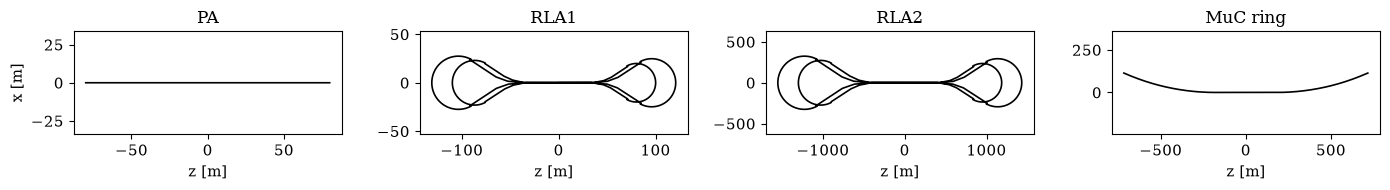

In [3]:
# Geometry overview (world x-z plane; the detector sits on the +z axis)
u = np.linspace(0, 1, 3000)
fig, axes = plt.subplots(1, 4, figsize=(14, 2))
for ax, (name, cfg) in zip(axes, machines.items()):
    lat = cfg["lattice"]
    ax.plot(lat.z(u) * 1e-2, lat.x(u) * 1e-2, lw=1.2, color="black")
    ax.set_title(name, fontsize=12)
    ax.set_xlabel("z [m]")
    ax.set_aspect("equal", adjustable="datalim")
axes[0].set_ylabel("x [m]")
fig.tight_layout()

## 2. Simulate the decays

One vegas run generates the master sample ($\bar\nu_\mu$, $P = 0$); each (machine,
flavor) case is a reweighted copy placed on that machine. Exposure per bunch:

- PA / RLA1 / RLA2: a single pass through the machine (`cycles = 1`);
- MuC ring: one full injection period (`cycles = "full_injection"`, machine turns
  computed from `ring.total_circumference`).

All machines are normalized to the same injection cycle: every injected bunch traverses
each accelerator stage once and is then stored in the collider ring, so a common
"bunches per year" (from the ring's $f_{\rm inj}$ and duty factor) applies to all.

In [4]:
N_EVALS = 5e6   # MC statistics; lower (e.g. 2e5) for quick runs

In [5]:
sim_base = MuDecaySimulator(
    muon_polarization=0.0,
    nuflavor="numubar",
    lattice=ring,
    cycles="full_injection",
    n_evals=N_EVALS,
    beam_dynamics=True,
)
ring_cycles = sim_base.cycles
print(f"machine turns per injection period (ring): {ring_cycles:.0f}")
sim_base.decay_muons()
print(f"vegas sample generated: {sim_base.sample_size} events")

sims = {name: {} for name in machines}
for name, cfg in machines.items():
    cycles = ring_cycles if name == "MuC ring" else 1
    for flavor in ["numubar", "nue"]:
        sim = sim_base.reweighted_copy(nuflavor=flavor)
        sim.cycles = cycles
        sim.place_muons_on_lattice(lattice=cfg["lattice"], direction="clockwise")
        sims[name][flavor] = sim
    print(f"placed {name} (cycles = {cycles:g})")

machine turns per injection period (ring): 5996
vegas sample generated: 4691839 events
placed PA (cycles = 1)
placed RLA1 (cycles = 1)
placed RLA2 (cycles = 1)


C:\Users\Joel Choi\Documents\MINT\mint\MuC.py:491: UserWarning: The lattice covers only 14.6% of the machine (arc length 1.465e+05 cm of total_circumference 1e+06 cm). Muon decays are placed on the covered section only; muon travel times account for propagation through the full machine.
  warnings.warn(


placed MuC ring (cycles = 5995.85)


## 3. Flux at a detector 1 km from the origin

Flux per cm$^2$ per GeV per year through a 2 m-radius detector face on the $+z$ axis,
1 km from the origin of each machine.

In [6]:
det_location = np.array([0.0, 0.0, 1e5])   # 1 km downstream, on axis
det_radius = 2e2                            # cm

bunches_per_year = ring.finj * ring.bunch_multiplicity * ring.duty_factor * const.s_in_year
print(f"Bunch crossings per year: {bunches_per_year:.2e}")

# Log-spaced bins spanning the PA (sub-GeV) through the collider ring (multi-TeV)
energy_edges = np.geomspace(1e-1, 6e3, 100)

fluxes = {}
for name in machines:
    fluxes[name] = {}
    for flavor in ["numubar", "nue"]:
        e_edges, flux = sims[name][flavor].get_flux_at_generic_location(
            det_location=det_location,
            det_radius=det_radius,
            ebins=energy_edges,
            per_cm2=True,
            normalization=bunches_per_year,
        )
        fluxes[name][flavor] = flux
        total = np.sum(flux * np.diff(energy_edges))
        print(f"{name} {flavor}: integrated flux {total:.3e} / cm^2 / year")

Bunch crossings per year: 5.02e+07
PA numubar: integrated flux 5.751e+09 / cm^2 / year
PA nue: integrated flux 5.624e+09 / cm^2 / year
RLA1 numubar: integrated flux 2.415e+10 / cm^2 / year
RLA1 nue: integrated flux 2.257e+10 / cm^2 / year
RLA2 numubar: integrated flux 1.783e+12 / cm^2 / year
RLA2 nue: integrated flux 1.782e+12 / cm^2 / year
MuC ring numubar: integrated flux 2.423e+13 / cm^2 / year
MuC ring nue: integrated flux 2.418e+13 / cm^2 / year


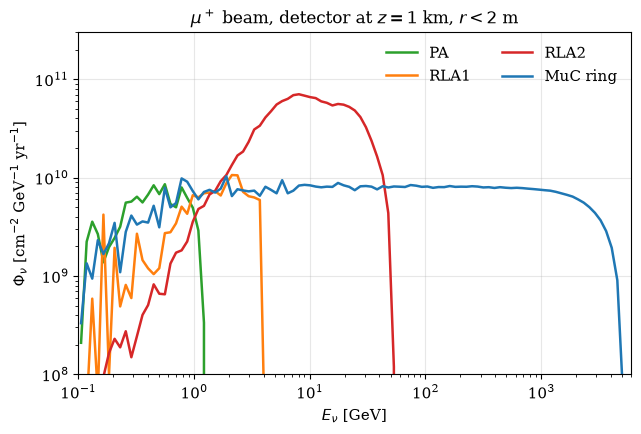

In [7]:
energy_centers = np.sqrt(energy_edges[1:] * energy_edges[:-1])

machine_colors = {
    "PA": "tab:green",
    "RLA1": "tab:orange",
    "RLA2": "tab:red",
    "MuC ring": "tab:blue",
}
flavor_style = {"numubar": ("-", r"$\bar\nu_\mu$")}#, "nue": ("--", r"$\nu_e$")}

fig, ax = pt.std_fig(figsize=(7, 4.5))
for name in machines:
    for flavor, (ls, _) in flavor_style.items():
        ax.plot(energy_centers, fluxes[name][flavor], ls=ls, lw=1.8,
                color=machine_colors[name])

# Legend: one color entry per machine, one linestyle entry per flavor
from matplotlib.lines import Line2D
machine_handles = [Line2D([], [], color=c, lw=1.8, label=n)
                   for n, c in machine_colors.items()]
# flavor_handles = [Line2D([], [], color="black", lw=1.8, ls=ls, label=lab)
#                   for ls, lab in flavor_style.values()]
ax.legend(handles=machine_handles, frameon=False,
          fontsize=11, ncol=2, loc="upper right")

ax.set_xscale("log")
ax.set_xlim(1e-1, 6e3)
ax.set_ylim(1e8, 3e11)
ax.set_yscale("log")
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$\Phi_\nu$ [cm$^{-2}$ GeV$^{-1}$ yr$^{-1}$]")
ax.set_title(rf"$\mu^+$ beam, detector at $z = 1$ km, $r < {det_radius * 1e-2:.0f}$ m")
ax.grid(True, which="major", ls="-", alpha=0.3)
fig.savefig("plots/machine_flux_comparison_1km.pdf", dpi=300, bbox_inches="tight")

## 4. Event rates in a $\rho \ell = 1$ kg/cm$^2$ detector

Interactions per year in a detector with nucleon column density $\rho\ell = 1$ kg/cm$^2$
and radius 2 m. To keep the geometry comparable across machines of very different size,
each detector sits at $z_{\rm det} = 2 \times z_{\rm max}$, twice the downstream
$z$-extent of its machine (160 m for the PA, up to a few km for RLA2 and the ring).

**Cross-section caveat:** the DIS tables in `mint.xsecs` start at 50 GeV (and return 0
below); below that edge we extrapolate linearly in $E_\nu$ (the DIS scaling
$\sigma \propto E$). At PA energies ($\lesssim 1$ GeV) the true cross section is
QE/resonance dominated, so those rates are rough estimates.

In [8]:
from mint import xsecs

# Detector: rho * L = 1 kg/cm^2, r = 2 m, at z_det = 2 x (z-extent of each lattice)
rho_L_g_cm2 = 1e3                      # rho * L = 1 kg/cm^2
nucleon_column_density = rho_L_g_cm2 / const.m_proton_in_g
det_radius = 2e2                       # cm
det_area_cm2 = np.pi * det_radius**2


def sigma_total_lowE(flavor):
    """total_xsecs with a linear-in-E extrapolation below the 50 GeV edge of the
    DIS table (which returns 0 there). sigma ~ E is the DIS scaling; at sub-GeV
    energies (PA) the true QE/RES cross section differs -- rough estimate only."""
    base = xsecs.total_xsecs[flavor]
    E0 = 50.0
    s0 = float(base(E0))
    return lambda E: np.where(np.asarray(E) >= E0, base(E), s0 * np.asarray(E) / E0)


e_centers = np.sqrt(energy_edges[1:] * energy_edges[:-1])
u_fine = np.linspace(0, 1, 5000)

event_rates, det_z_m = {}, {}
for name, cfg in machines.items():
    z_extent = float(np.max(cfg["lattice"].z(u_fine)))
    det_loc = np.array([0.0, 0.0, 2.0 * z_extent])
    det_z_m[name] = det_loc[2] * 1e-2
    event_rates[name] = {}
    for flavor in ["numubar", "nue"]:
        _, flux = sims[name][flavor].get_flux_at_generic_location(
            det_location=det_loc,
            det_radius=det_radius,
            ebins=energy_edges,
            per_cm2=True,
            normalization=bunches_per_year,
        )
        dN_dE = (flux * det_area_cm2 * sigma_total_lowE(flavor)(e_centers)
                 * nucleon_column_density)
        event_rates[name][flavor] = dN_dE
        total = np.sum(dN_dE * np.diff(energy_edges))
        print(f"{name} (detector at z = {det_z_m[name]:.0f} m): "
              f"{flavor} {total:.4g} events / year")


PA (detector at z = 160 m): numubar 7.677e+04 events / year
PA (detector at z = 160 m): nue 1.345e+05 events / year
RLA1 (detector at z = 242 m): numubar 2.759e+05 events / year
RLA1 (detector at z = 242 m): nue 4.806e+05 events / year
RLA2 (detector at z = 2861 m): numubar 1.75e+06 events / year
RLA2 (detector at z = 2861 m): nue 3.042e+06 events / year
MuC ring (detector at z = 1433 m): numubar 1.531e+10 events / year
MuC ring (detector at z = 1433 m): nue 2.19e+10 events / year


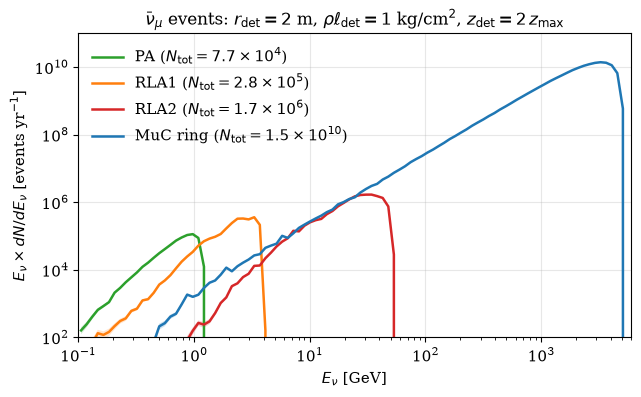

In [9]:
from mint import plot_tools as pt
fig, ax = pt.std_fig(figsize=(7, 4))
for name in machines:
    y = event_rates[name]["numubar"]
    dE = np.diff(energy_edges)

    # Poisson uncertainty per bin: N_bin = (dN/dE) * dE
    n_bin = y * dE
    yerr = np.sqrt(np.clip(n_bin, 0.0, None)) / dE
    total = np.sum(n_bin)

    ax.plot(
        e_centers, e_centers*y, "-", lw=1.8,
        color=machine_colors[name],
        label=rf"{name} ($N_{{\rm tot}} = {pt.sci_notation(total, precision=1, notex=True)}$)"
    )
    ax.fill_between(
        e_centers,
        np.clip(e_centers*(y - yerr), 1e-30, None),
        e_centers*(y + yerr),
        color=machine_colors[name],
        alpha=0.20,
        linewidth=0,
    )
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-1, 6e3)
ax.set_ylim(1e2, 1e11)
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$E_\nu \times dN/dE_\nu$ [events yr$^{-1}$]")
ax.set_title(r"$\bar\nu_\mu$ events: $r_{\rm det} = 2$ m, "
             r"$\rho \ell_{\rm det} = 1$ kg/cm$^2$, $z_{\rm det} = 2\, z_{\rm max}$")
ax.grid(True, which="major", ls="-", alpha=0.3)
ax.legend(frameon=False, fontsize=11, loc='upper left', ncol=1)
fig.savefig("plots/machine_event_rate_2zmax.pdf", dpi=300, bbox_inches="tight")

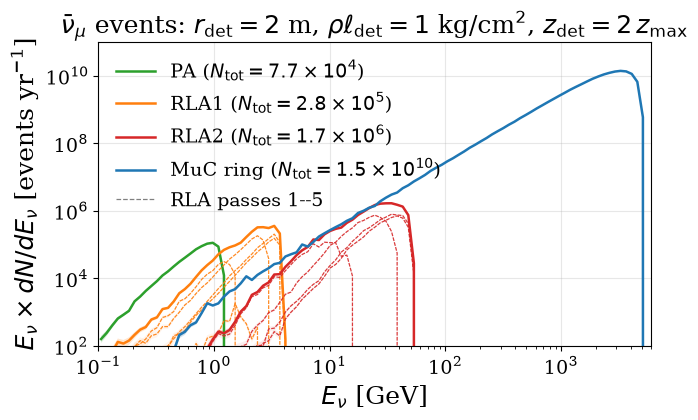

In [10]:
# Same event-rate plot, with the RLA curves split into their linac passes.
# which_pass(u) = 1..5 tags each decay with its traversal of the machine; the beam
# momentum grows pass by pass, so later passes contribute harder neutrinos.
# Passes are masked with get_flux_at_generic_location(mask=...) and sum exactly
# to the solid total.
from matplotlib.lines import Line2D

fig, ax = pt.std_fig(figsize=(7, 4))
dE = np.diff(energy_edges)
sigma_numubar = sigma_total_lowE("numubar")(e_centers)

for name, cfg in machines.items():
    y = event_rates[name]["numubar"]

    # Poisson uncertainty per bin: N_bin = (dN/dE) * dE
    n_bin = y * dE
    yerr = np.sqrt(np.clip(n_bin, 0.0, None)) / dE
    total = np.sum(n_bin)

    ax.plot(
        e_centers, e_centers * y, "-", lw=1.8,
        color=machine_colors[name],
        label=rf"{name} ($N_{{\rm tot}} = {pt.sci_notation(total, precision=1, notex=True)}$)"
    )
    ax.fill_between(
        e_centers,
        np.clip(e_centers * (y - yerr), 1e-30, None),
        e_centers * (y + yerr),
        color=machine_colors[name],
        alpha=0.20,
        linewidth=0,
    )

    if name not in ("RLA1", "RLA2"):
        continue

    # Per-pass contributions (thin dashed, same color as the machine)
    lat = cfg["lattice"]
    sim = sims[name]["numubar"]
    z_extent = float(np.max(lat.z(np.linspace(0, 1, 5000))))
    det_loc = np.array([0.0, 0.0, 2.0 * z_extent])
    pass_id = np.rint(np.asarray(lat.which_pass(lat.inv_s(sim.s_in_turn)))).astype(int)

    for k in np.unique(pass_id):
        _, flux_k = sim.get_flux_at_generic_location(
            det_location=det_loc,
            det_radius=det_radius,
            ebins=energy_edges,
            per_cm2=True,
            normalization=bunches_per_year,
            mask=(pass_id == k),
        )
        if np.isscalar(flux_k):
            continue
        y_k = flux_k * det_area_cm2 * sigma_numubar * nucleon_column_density
        n_bin_k = y_k * dE
        yerr_k = np.sqrt(np.clip(n_bin_k, 0.0, None)) / dE

        ax.plot(
            e_centers, e_centers * y_k,
            ls=(1, (3, 1)), lw=0.9, alpha=0.9, color=machine_colors[name]
        )
        ax.fill_between(
            e_centers,
            np.clip(e_centers * (y_k - yerr_k), 1e-30, None),
            e_centers * (y_k + yerr_k),
            color=machine_colors[name],
            alpha=0.08,
            linewidth=0,
        )

handles, _ = ax.get_legend_handles_labels()
handles.append(Line2D([], [], color="gray", ls="--", lw=0.9, label="RLA passes 1--5"))

ax.set_yticks([1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9, 1e10])
ax.tick_params(axis="both", which="major", labelsize=14)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-1, 6e3)
ax.set_ylim(1e2, 1e11)
ax.set_xlabel(r"$E_\nu$ [GeV]", fontsize=18)
ax.set_ylabel(r"$E_\nu \times dN/dE_\nu$ [events yr$^{-1}$]", fontsize=18)
ax.set_title(r"$\bar\nu_\mu$ events: $r_{\rm det} = 2$ m, "
             r"$\rho \ell_{\rm det} = 1$ kg/cm$^2$, $z_{\rm det} = 2\, z_{\rm max}$", fontsize=18)
ax.grid(True, which="major", ls="-", alpha=0.3)
ax.legend(handles=handles, frameon=False, fontsize=14, loc="upper left", ncol=1)
fig.savefig("plots/machine_event_rate_2zmax_passes.pdf", dpi=300, bbox_inches="tight")

## 5. Same studies without beam dynamics

Placement with `beam_dynamics = False`: muons sit exactly on the reference orbit with
zero transverse size, divergence, and momentum spread, so the neutrino angular spread is
purely from the decay kinematics ($\theta \sim 1/\gamma_\mu$).

To keep the memory footprint flat with the $10^7$-event sample, each no-BD copy is
discarded (`del sim`) as soon as its fluxes are computed.

In [11]:
fluxes_nobd, event_rates_nobd, det_z_m = {}, {}, {}
u_fine = np.linspace(0, 1, 5000)

for name, cfg in machines.items():
    fluxes_nobd[name], event_rates_nobd[name] = {}, {}
    z_extent = float(np.max(cfg["lattice"].z(u_fine)))
    det_z_m[name] = 2.0 * z_extent * 1e-2
    cycles = ring_cycles if name == "MuC ring" else 1
    for flavor in ["numubar", "nue"]:
        sim = sim_base.reweighted_copy(nuflavor=flavor)
        sim.cycles = cycles
        sim.beam_dynamics = False
        sim.place_muons_on_lattice(lattice=cfg["lattice"], direction="clockwise")

        # flux through the 1 km, r < 2 m detector face (as in section 3)
        _, flux_1km = sim.get_flux_at_generic_location(
            det_location=np.array([0.0, 0.0, 1e5]),
            det_radius=det_radius,
            ebins=energy_edges,
            per_cm2=True,
            normalization=bunches_per_year,
        )
        fluxes_nobd[name][flavor] = flux_1km

        # event rate in the rho*L = 1 kg/cm^2 detector at z = 2 z_max (as in section 4)
        _, flux_det = sim.get_flux_at_generic_location(
            det_location=np.array([0.0, 0.0, 2.0 * z_extent]),
            det_radius=det_radius,
            ebins=energy_edges,
            per_cm2=True,
            normalization=bunches_per_year,
        )
        event_rates_nobd[name][flavor] = (
            flux_det * det_area_cm2 * sigma_total_lowE(flavor)(e_centers)
            * nucleon_column_density
        )
        del sim   # free the placement before the next copy
    print(f"{name}: no-BD fluxes and event rates computed")

PA: no-BD fluxes and event rates computed
RLA1: no-BD fluxes and event rates computed
RLA2: no-BD fluxes and event rates computed
MuC ring: no-BD fluxes and event rates computed


PA numubar (no BD): integrated flux 5.838e+09 / cm^2 / year
RLA1 numubar (no BD): integrated flux 2.275e+10 / cm^2 / year
RLA2 numubar (no BD): integrated flux 2.438e+12 / cm^2 / year
MuC ring numubar (no BD): integrated flux 2.443e+13 / cm^2 / year


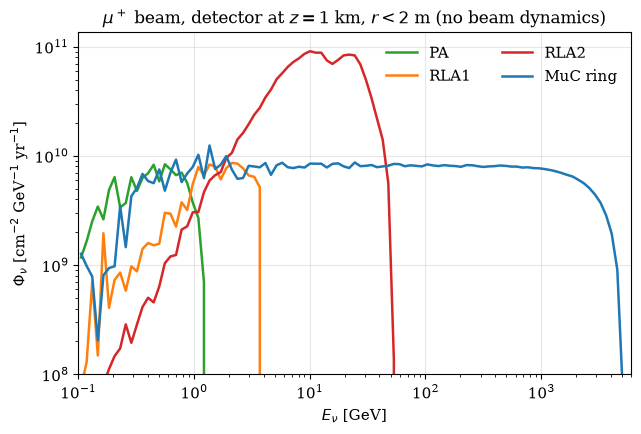

In [12]:
# Flux at 1 km, no beam dynamics (same style as section 3)
fig, ax = pt.std_fig(figsize=(7, 4.5))
for name in machines:
    ax.plot(e_centers, fluxes_nobd[name]["numubar"], "-", lw=1.8,
            color=machine_colors[name], label=name)
    total = np.sum(fluxes_nobd[name]["numubar"] * np.diff(energy_edges))
    print(f"{name} numubar (no BD): integrated flux {total:.3e} / cm^2 / year")

ax.legend(frameon=False, fontsize=11, ncol=2, loc="upper right")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-1, 6e3)
ax.set_ylim(1e8, None)
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$\Phi_\nu$ [cm$^{-2}$ GeV$^{-1}$ yr$^{-1}$]")
ax.set_title(rf"$\mu^+$ beam, detector at $z = 1$ km, $r < {det_radius * 1e-2:.0f}$ m (no beam dynamics)")
ax.grid(True, which="major", ls="-", alpha=0.3)
fig.savefig("plots/machine_flux_comparison_1km_noBD.pdf", dpi=300, bbox_inches="tight")

PA (detector at z = 160 m, no BD): numubar 7.664e+04 events / year
PA (detector at z = 160 m, no BD): nue 1.344e+05 events / year
RLA1 (detector at z = 242 m, no BD): numubar 2.853e+05 events / year
RLA1 (detector at z = 242 m, no BD): nue 4.926e+05 events / year
RLA2 (detector at z = 2861 m, no BD): numubar 3.748e+06 events / year
RLA2 (detector at z = 2861 m, no BD): nue 6.558e+06 events / year
MuC ring (detector at z = 1433 m, no BD): numubar 1.576e+10 events / year
MuC ring (detector at z = 1433 m, no BD): nue 2.262e+10 events / year


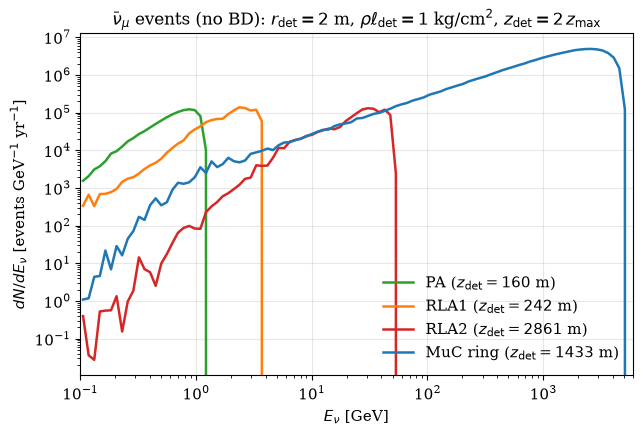

In [13]:
# Event rates at z = 2 z_max, no beam dynamics (same style as section 4)
fig, ax = pt.std_fig(figsize=(7, 4.5))
for name in machines:
    ax.plot(e_centers, event_rates_nobd[name]["numubar"], "-", lw=1.8,
            color=machine_colors[name],
            label=rf"{name} ($z_{{\rm det}} = {det_z_m[name]:.0f}$ m)")
    for flavor in ["numubar", "nue"]:
        total = np.sum(event_rates_nobd[name][flavor] * np.diff(energy_edges))
        print(f"{name} (detector at z = {det_z_m[name]:.0f} m, no BD): "
              f"{flavor} {total:.4g} events / year")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-1, 6e3)
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$dN/dE_\nu$ [events GeV$^{-1}$ yr$^{-1}$]")
ax.set_title(r"$\bar\nu_\mu$ events (no BD): $r_{\rm det} = 2$ m, "
             r"$\rho \ell_{\rm det} = 1$ kg/cm$^2$, $z_{\rm det} = 2\, z_{\rm max}$")
ax.grid(True, which="major", ls="-", alpha=0.3)
ax.legend(frameon=False, fontsize=11)
fig.savefig("plots/machine_event_rate_2zmax_noBD.pdf", dpi=300, bbox_inches="tight")

## 6. Full-acceptance detector: spherical shell with $\rho \ell = 1$ kg/cm $^2$

A closed shell around the machine catches **every** neutrino, so the geometry drops out
entirely: the event rate is the total neutrino production spectrum times the interaction
probability,
$dN/dE = (d\Phi_\nu/dE)\, \sigma(E)\, \rho\ell / m_p$.
No detector placement is involved, and beam dynamics are irrelevant at this level (the
BD-on simulations are used). This is the ceiling on what any detector arrangement could
collect per machine.

PA numubar: 2.872e+18 neutrinos / year -> 2.234e+06 events / year
PA nue: 2.622e+18 neutrinos / year -> 3.777e+06 events / year
RLA1 numubar: 6.634e+18 neutrinos / year -> 1.754e+07 events / year
RLA1 nue: 6.533e+18 neutrinos / year -> 3.052e+07 events / year
RLA2 numubar: 8.052e+18 neutrinos / year -> 2.144e+08 events / year
RLA2 nue: 8.040e+18 neutrinos / year -> 3.737e+08 events / year
MuC ring numubar: 1.257e+19 neutrinos / year -> 6.658e+10 events / year
MuC ring nue: 1.256e+19 neutrinos / year -> 9.545e+10 events / year


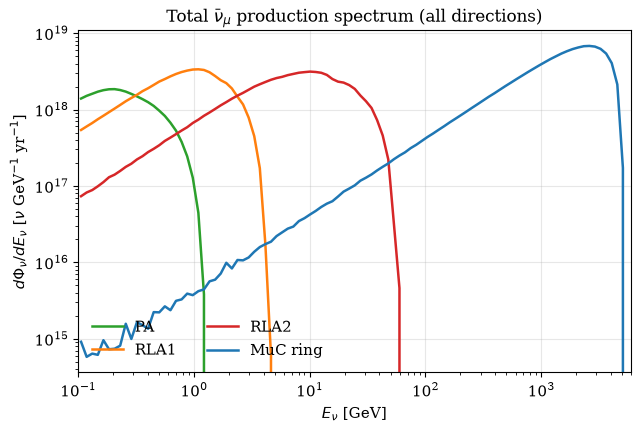

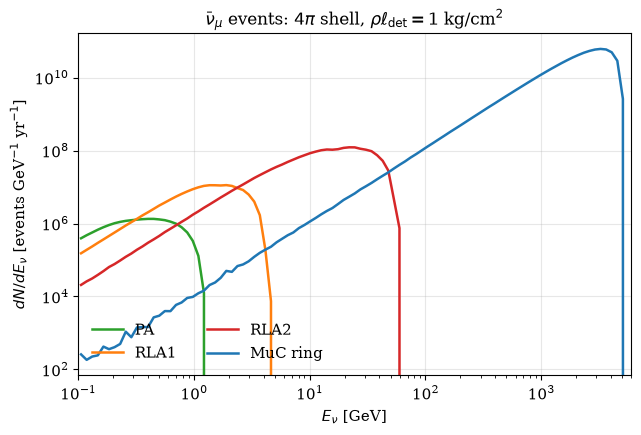

In [14]:
nu_spectra_4pi, event_rates_4pi = {}, {}
for name in machines:
    nu_spectra_4pi[name], event_rates_4pi[name] = {}, {}
    for flavor in ["numubar", "nue"]:
        sim = sims[name][flavor]
        counts, _ = np.histogram(sim.pnu["E"], bins=energy_edges,
                                 weights=sim.weights.flatten() * bunches_per_year)
        dPhi_dE = counts / np.diff(energy_edges)       # neutrinos / GeV / year
        nu_spectra_4pi[name][flavor] = dPhi_dE
        event_rates_4pi[name][flavor] = (
            dPhi_dE * sigma_total_lowE(flavor)(e_centers) * nucleon_column_density
        )
        total_nu = np.sum(counts)
        total_ev = np.sum(event_rates_4pi[name][flavor] * np.diff(energy_edges))
        print(f"{name} {flavor}: {total_nu:.3e} neutrinos / year "
              f"-> {total_ev:.4g} events / year")

# Total neutrino production spectrum
fig, ax = pt.std_fig(figsize=(7, 4.5))
for name in machines:
    ax.plot(e_centers, e_centers*nu_spectra_4pi[name]["numubar"], "-", lw=1.8,
            color=machine_colors[name], label=name)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-1, 6e3)
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$d\Phi_\nu/dE_\nu$ [$\nu$ GeV$^{-1}$ yr$^{-1}$]")
ax.set_title(r"Total $\bar\nu_\mu$ production spectrum (all directions)")
ax.grid(True, which="major", ls="-", alpha=0.3)
ax.legend(frameon=False, fontsize=11, ncol=2, loc="lower left")
fig.savefig("plots/machine_nu_spectrum_4pi.pdf", dpi=300, bbox_inches="tight")

# Event-rate spectrum in the shell
fig, ax = pt.std_fig(figsize=(7, 4.5))
for name in machines:
    ax.plot(e_centers, e_centers*event_rates_4pi[name]["numubar"], "-", lw=1.8,
            color=machine_colors[name], label=name)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-1, 6e3)
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$dN/dE_\nu$ [events GeV$^{-1}$ yr$^{-1}$]")
ax.set_title(r"$\bar\nu_\mu$ events: $4\pi$ shell, $\rho \ell_{\rm det} = 1$ kg/cm$^2$")
ax.grid(True, which="major", ls="-", alpha=0.3)
ax.legend(frameon=False, fontsize=11, ncol=2, loc="lower left")
fig.savefig("plots/machine_event_rate_4pi.pdf", dpi=300, bbox_inches="tight")

## 7. DUNE Far Detector Study

[This link](https://news.fnal.gov/2026/05/fermilab-marks-major-milestone-for-world-leading-dune-experiment/?utm_source=chatgpt.com) says the detector complex is 65.84m (215 ft) long so with very rough estimate assuming all liquid argon, $\rho l = 9.2176$ kg/cm $^2$.

The rectangular surface is 18.9m x 18.29m (62ft x 60ft) so we assume radius $r_{det} \approx 10.5m$

In [15]:
rho_L_g_cm2 = 9.2176e3
nucleon_column_density = rho_L_g_cm2 / const.m_proton_in_g
det_radius = 10.5e3                       # cm
det_area_cm2 = np.pi * det_radius**2

det_location = np.array([0.0, 0.0, 1300e5])

In [16]:
event_rates, det_z_m = {}, {}
for name, cfg in machines.items():
    z_extent = float(np.max(cfg["lattice"].z(u_fine)))
    event_rates[name] = {}
    for flavor in ["numubar", "nue"]:
        _, flux = sims[name][flavor].get_flux_at_generic_location(
            det_location=det_location,
            det_radius=det_radius,
            ebins=energy_edges,
            per_cm2=True,
            normalization=bunches_per_year,
        )
        dN_dE = (flux * det_area_cm2 * sigma_total_lowE(flavor)(e_centers)
                 * nucleon_column_density)
        event_rates[name][flavor] = dN_dE
        total = np.sum(dN_dE * np.diff(energy_edges))
        print(f"{name} (detector at z = {det_location[2] * 1e-5:.0f} km): "
              f"{flavor} {total:.4g} events / year")

PA (detector at z = 1300 km): numubar 0.1065 events / year
PA (detector at z = 1300 km): nue 16.91 events / year
RLA1 (detector at z = 1300 km): numubar 432.3 events / year
RLA1 (detector at z = 1300 km): nue 482.9 events / year
RLA2 (detector at z = 1300 km): numubar 2.275e+05 events / year
RLA2 (detector at z = 1300 km): nue 3.967e+05 events / year
MuC ring (detector at z = 1300 km): numubar 2.312e+10 events / year
MuC ring (detector at z = 1300 km): nue 3.33e+10 events / year


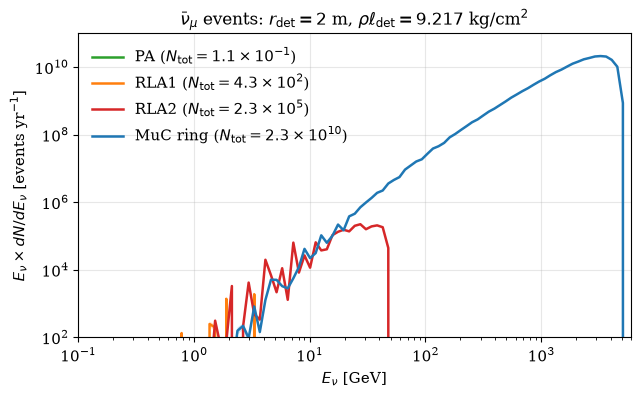

In [17]:
from mint import plot_tools as pt
fig, ax = pt.std_fig(figsize=(7, 4))
for name in machines:
    y = event_rates[name]["numubar"]
    dE = np.diff(energy_edges)

    # Poisson uncertainty per bin: N_bin = (dN/dE) * dE
    n_bin = y * dE
    yerr = np.sqrt(np.clip(n_bin, 0.0, None)) / dE
    total = np.sum(n_bin)

    ax.plot(
        e_centers, e_centers*y, "-", lw=1.8,
        color=machine_colors[name],
        label=rf"{name} ($N_{{\rm tot}} = {pt.sci_notation(total, precision=1, notex=True)}$)"
    )
    ax.fill_between(
        e_centers,
        np.clip(e_centers*(y - yerr), 1e-30, None),
        e_centers*(y + yerr),
        color=machine_colors[name],
        alpha=0.20,
        linewidth=0,
    )
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-1, 6e3)
ax.set_ylim(1e2, 1e11)
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$E_\nu \times dN/dE_\nu$ [events yr$^{-1}$]")
ax.set_title(r"$\bar\nu_\mu$ events: $r_{\rm det} = 2$ m, "
             r"$\rho \ell_{\rm det} = 9.217$ kg/cm$^2$")
ax.grid(True, which="major", ls="-", alpha=0.3)
ax.legend(frameon=False, fontsize=11, loc='upper left', ncol=1)
# fig.savefig("plots/machine_event_rate_2zmax.pdf", dpi=300, bbox_inches="tight")

Look for $1/r^2$ behavior

PA: 1/r^2 regime begins at z ~ 412.5 m
RLA1: 1/r^2 regime begins at z ~ 142.5 m
RLA2: 1/r^2 regime begins at z ~ 1425.1 m
MuC ring: 1/r^2 regime begins at z ~ 10.0 m


C:\Users\Joel Choi\AppData\Local\Temp\ipykernel_13660\2357971115.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


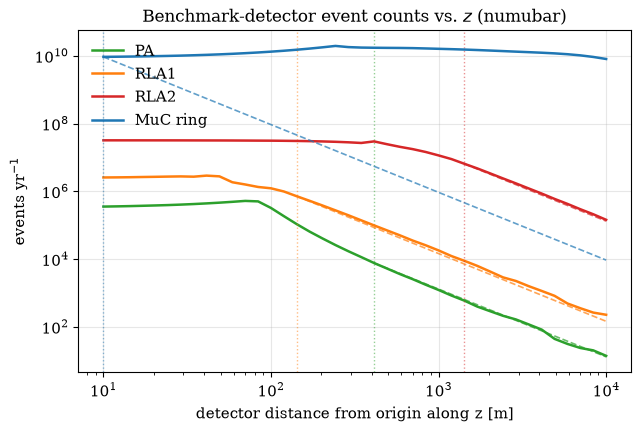

In [25]:
def plot_event_counts_vs_distance(flavor="numubar", z_range_m=(10, 1e4), n_points=40):
    """Total benchmark-detector event count as a function of detector z-distance.

    The dashed 1/z^2 reference is anchored at the first distance where the local
    log-log slope of the event-count curve is consistent with -2, i.e. where the
    geometric falloff has entered its asymptotic regime.
    """
    z_vals = np.geomspace(*z_range_m, n_points)
    rho_L_g_cm2 = 1e3
    det_radius_cm = 2e2
    det_area_cm2 = np.pi * det_radius_cm**2
    nucleon_column_density = rho_L_g_cm2 / const.m_proton_in_g

    counts_by_machine = {}
    onset_by_machine = {}
    for name in machines:
        counts = []
        for z_det_m in z_vals:
            det_location = np.array([0.0, 0.0, z_det_m * 1e2])  # cm
            _, flux = sims[name][flavor].get_flux_at_generic_location(
                det_location=det_location,
                det_radius=det_radius_cm,
                ebins=energy_edges,
                per_cm2=True,
                normalization=bunches_per_year,
            )
            dN_dE = (
                flux * det_area_cm2 * sigma_total_lowE(flavor)(e_centers)
                * nucleon_column_density
            )
            counts.append(np.sum(dN_dE * np.diff(energy_edges)))
        counts_by_machine[name] = np.asarray(counts)

        y = counts_by_machine[name]
        valid = np.isfinite(y) & (y > 0)
        if valid.sum() < 3:
            onset_idx = 0
        else:
            z_fit = z_vals[valid]
            y_fit = y[valid]
            logz = np.log10(z_fit)
            logy = np.log10(y_fit)
            slope = np.gradient(logy, logz)
            idx = np.where(np.abs(slope + 2.0) < 0.25)[0]
            onset_idx = int(idx[0]) if idx.size else 0

        onset_by_machine[name] = z_vals[valid][onset_idx]

    fig, ax = pt.std_fig(figsize=(7, 4.5))
    for name in machines:
        y = counts_by_machine[name]
        ax.plot(
            z_vals,
            y,
            "-",
            lw=1.8,
            color=machine_colors[name],
            label=name,
        )

        z0 = onset_by_machine[name]
        y0 = np.interp(z0, z_vals, y)
        mask = z_vals >= z0
        if np.any(mask):
            ax.plot(
                z_vals[mask],
                y0 * (z0 / z_vals[mask]) ** 2,
                "--",
                color=machine_colors[name],
                lw=1.2,
                alpha=0.7,
            )
            ax.axvline(z0, color=machine_colors[name], ls=":", lw=1.0, alpha=0.5)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("detector distance from origin along z [m]")
    ax.set_ylabel(r"events yr$^{-1}$")
    ax.set_title(rf"Benchmark-detector event counts vs. $z$ ({flavor})")
    ax.grid(True, which="major", ls="-", alpha=0.3)
    ax.legend(frameon=False, fontsize=11, loc="upper left")
    fig.tight_layout()
    return fig, ax, z_vals, counts_by_machine, onset_by_machine


fig, ax, z_vals, counts_by_machine, onset_by_machine = plot_event_counts_vs_distance(flavor="numubar")
for name, z0 in onset_by_machine.items():
    print(f"{name}: 1/r^2 regime begins at z ~ {z0:.1f} m")
fig.savefig("plots/machine_event_counts_vs_distance.pdf", dpi=300, bbox_inches="tight")


## 8. RLA2 flavor oscillations

Propagate the RLA2 beam to the DUNE-like baseline using three-flavor vacuum oscillations. Replace the values in `nufit` with the NuFIT best fit (or a sampled parameter point). The baseline is treated as fixed because the decay-point spread along RLA2 is negligible compared with 1300 km.

RLA2 detected nue: 1.406e+04 events / year
RLA2 detected numu: 2.877 events / year
RLA2 detected nutau: 4.275 events / year
RLA2 detected nuebar: 21.24 events / year
RLA2 detected numubar: 1.032e+05 events / year
RLA2 detected nutaubar: 556.8 events / year


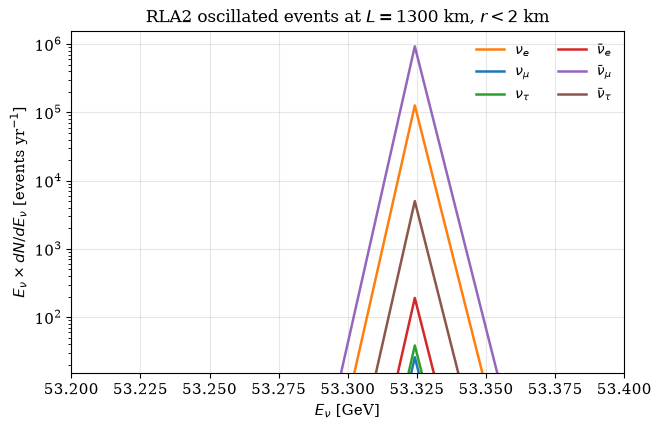

In [21]:
# NuFIT inputs: replace these numbers with the NuFIT release you want to use.
nufit = {
    "theta12_deg": 33.68,
    "theta13_deg": 8.56,
    "theta23_deg": 43.3,
    "delta_cp_deg": 212.0,
    "dm21_eV2": 7.49e-5,
    "dm31_eV2": 2.513e-3,
}


def pmns_matrix(params):
    """PDG-convention PMNS matrix, including the Dirac CP phase."""
    t12, t13, t23, delta = np.deg2rad([
        params["theta12_deg"], params["theta13_deg"],
        params["theta23_deg"], params["delta_cp_deg"],
    ])
    s12, c12 = np.sin(t12), np.cos(t12)
    s13, c13 = np.sin(t13), np.cos(t13)
    s23, c23 = np.sin(t23), np.cos(t23)
    phase = np.exp(1j * delta)
    return np.array([
        [c12 * c13, s12 * c13, s13 / phase],
        [-s12 * c23 - c12 * s23 * s13 * phase,
         c12 * c23 - s12 * s23 * s13 * phase, s23 * c13],
        [s12 * s23 - c12 * c23 * s13 * phase,
         -c12 * s23 - s12 * c23 * s13 * phase, c23 * c13],
    ])


def oscillation_probabilities(E_GeV, baseline_km, params, antineutrino=False):
    """Return P[initial flavor, detected flavor, energy] in vacuum."""
    energies = np.asarray(E_GeV, dtype=float)
    if np.any(energies <= 0):
        raise ValueError("oscillation energies must be positive")
    U = pmns_matrix(params)
    if antineutrino:
        U = U.conj()
    mass2 = np.array([0.0, params["dm21_eV2"], params["dm31_eV2"]])
    phase = np.exp(-2j * 1.267 * mass2[:, None] * baseline_km / energies[None, :])
    amplitude = np.einsum("bi,ai,ie->bae", U, U.conj(), phase)
    return np.abs(amplitude) ** 2


# At 1300 km the nominal 10.5 m DUNE face has negligible RLA2 MC acceptance
# because the RLA2 beam divergence is about 1 mrad. Use a large scoring disk here
# to obtain a stable spectrum; change this to a physical detector radius as needed.
rla2_baseline_km = det_location[2] * 1e-5
osc_detector_radius = 2.0e5       # cm = 2 km
osc_detector_area = np.pi * osc_detector_radius**2
rla2_flux = {}
for source in ("nue", "numubar"):
    _, rla2_flux[source] = sims["RLA2"][source].get_flux_at_generic_location(
        det_location=det_location,
        det_radius=osc_detector_radius,
        ebins=energy_edges,
        per_cm2=True,
        normalization=bunches_per_year,
    )

P_nu = oscillation_probabilities(e_centers, rla2_baseline_km, nufit)
P_nubar = oscillation_probabilities(
    e_centers, rla2_baseline_km, nufit, antineutrino=True
)

initial_flavors = ("e", "mu", "tau")
flux_by_detected = {}
for i, flavor in enumerate(initial_flavors):
    flux_by_detected[f"nu{flavor}"] = rla2_flux["nue"] * P_nu[0, i]
    flux_by_detected[f"nu{flavor}bar"] = rla2_flux["numubar"] * P_nubar[1, i]


def sigma_for_detected_flavor(energy, flavor):
    """Total DIS cross section for one detected neutrino species."""
    antineutrino = flavor.endswith("bar")
    base = flavor[:-3] if antineutrino else flavor
    if base == "nutau":
        return (xsecs.sigma_nutaubar_CC(energy) if antineutrino
                else xsecs.sigma_nutau_CC(energy)) + (
                    xsecs.sigma_NC_nubar(energy) if antineutrino
                    else xsecs.sigma_NC_nu(energy))
    return xsecs.total_xsecs["nuebar" if antineutrino else "nue"](energy)


osc_event_rates = {
    flavor: flux * osc_detector_area
    * sigma_for_detected_flavor(e_centers, flavor) * nucleon_column_density
    for flavor, flux in flux_by_detected.items()
}

flavor_labels = {
    "nue": r"$\nu_e$", "numu": r"$\nu_\mu$", "nutau": r"$\nu_\tau$",
    "nuebar": r"$\bar\nu_e$", "numubar": r"$\bar\nu_\mu$", "nutaubar": r"$\bar\nu_\tau$",
}
flavor_colors = {
    "nue": "tab:orange", "numu": "tab:blue", "nutau": "tab:green",
    "nuebar": "tab:red", "numubar": "tab:purple", "nutaubar": "tab:brown",
}
fig, ax = pt.std_fig(figsize=(7, 4.5))
for flavor in flavor_labels:
    y = osc_event_rates[flavor]
    total = np.sum(y * np.diff(energy_edges))
    print(f"RLA2 detected {flavor}: {total:.4g} events / year")
    ax.plot(e_centers, e_centers * y, lw=1.8, color=flavor_colors[flavor],
            label=flavor_labels[flavor])
# ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(53.2,53.4)
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$E_\nu \times dN/dE_\nu$ [events yr$^{-1}$]")
ax.set_title(rf"RLA2 oscillated events at $L = {rla2_baseline_km:.0f}$ km, $r < 2$ km")
ax.grid(True, which="major", ls="-", alpha=0.3)
ax.legend(frameon=False, ncol=2)
fig.savefig("plots/rla2_oscillated_event_rates.pdf", dpi=300, bbox_inches="tight")